# MMC Chatbot — Advanced Analysis (Responses)

Topic modeling, mixed coding, needs mapping, and cross-cuts over the **946
chatbot users** in `MMC_bot_responses`. Companion to `analysis_meal.ipynb`
(satisfaction). Every section opens with **What this shows / Why it matters**;
non-obvious choices get a **Technical note**. Follow it top-to-bottom without
reading code.

> **Technical note — user-level, self-reported data.** One row per WhatsApp
> user; all of a user's messages are concatenated. There is no per-turn log and
> no bot-output text, which bounds what we can measure (see the final
> *Data gaps* section).

In [1]:
import sys, warnings
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from palette import *          # blue ramp, bar_colors(), rcParams
import mmc_data, mmc_entities, mmc_text

df = mmc_data.load_responses()
meal = mmc_data.load_meal()
print(f"responses: {len(df)} rows  |  meal: {len(meal)} rows")

responses: 946 rows  |  meal: 78 rows


## 1. Loading & cleaning

**What this shows.** How many users we have, how complete each field is, and
what cleaning was applied. **Why it matters.** Every later number rests on
these records being correctly parsed and de-duplicated.

In [2]:
summary = pd.DataFrame({
    "non_null": df.notna().sum(),
    "pct": (df.notna().mean() * 100).round(1),
})
display(summary.loc[["Nationality","city_clean","age_num","Gender",
                     "Minors","Messages","Chat_summary","n_questions","ts"]])
print("date range:", df["ts"].min(), "→", df["ts"].max())
print("unique phones:", df["phone"].nunique())

,non_null,pct
Nationality,919,97.1
city_clean,946,100.0
age_num,946,100.0
Gender,946,100.0
Minors,946,100.0
Messages,835,88.3
Chat_summary,844,89.2
n_questions,941,99.5
ts,946,100.0


date range: 2026-03-25 13:43:06.306000 → 2026-07-03 06:16:46.166000
unique phones: 917


## 2. Topic modeling & clustering

**What this shows.** Conversations grouped automatically by theme — no manual
labeling. **Why it matters.** It reveals what people actually ask about and
gives every later section a shared topic dimension.

> **Technical note.** We embed the English translation (`Text`) with the
> multilingual `paraphrase-multilingual-MiniLM-L12-v2` model, then let BERTopic
> (UMAP → HDBSCAN → c-TF-IDF) find clusters. `-1` is the outlier topic. A fixed
> `random_state` makes UMAP reproducible.

In [3]:
from sentence_transformers import SentenceTransformer
from umap import UMAP
from bertopic import BERTopic

docs_mask = df["Text"].notna() & (df["Text"].astype(str).str.len() > 0)
docs = df.loc[docs_mask, "Text"].astype(str).tolist()

embedder = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
embeddings = embedder.encode(docs, show_progress_bar=False)

umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0,
                  metric='cosine', random_state=42)
topic_model = BERTopic(umap_model=umap_model, language='multilingual',
                       min_topic_size=10, calculate_probabilities=False)
topics, _ = topic_model.fit_transform(docs, embeddings)

df["topic"] = -2                     # -2 = no text / not modeled
df.loc[docs_mask, "topic"] = topics
topic_info = topic_model.get_topic_info()
label_map = dict(zip(topic_info["Topic"], topic_info["Name"]))
label_map[-2] = "no message"
df["topic_label"] = df["topic"].map(label_map)
topic_info.head(20)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

,Topic,Count,Name,Representation,Representative_Docs
0,-1,169,-1_to_and_have_in,"[to, and, have, in, the, my, am, can, for, that]",[I need information about the temporary protec...
1,0,118,0_colombia_in_colombian_to,"[colombia, in, colombian, to, and, here, the, ...",[I am Venezuelan and I do not have documents i...
2,1,66,1_ppt_the_my_get,"[ppt, the, my, get, rumv, know, they, want, to...","[I can get the ppt, Can I get the PPT?, I want..."
3,2,59,2_safe_conduct_permit_pass,"[safe, conduct, permit, pass, residence, the, ...","[How do I apply for the safe-conduct pass?, Ho..."
4,3,49,3_hello_you_good_questions,"[hello, you, good, questions, re, welcome, yes...","[You're welcome, You're welcome, You're welcome]"
5,4,44,4_venezuelans_for_aid_venezuelan,"[venezuelans, for, aid, venezuelan, there, is,...",[I would like to know if there is any type of ...
6,5,43,5_humanitarian_aid_would_like,"[humanitarian, aid, would, like, know, assista...","[humanitarian aid, Humanitarian aid, Humanitar..."
7,6,33,6_job_employment_find_looking,"[job, employment, find, looking, want, get, to...","[I want to have a job, I want a job, I want a ..."
8,7,32,7_entrepreneurship_business_for_help,"[entrepreneurship, business, for, help, suppor...","[Entrepreneurship, Hello, I would like to know..."
9,8,29,8_health_help_me_need,"[health, help, me, need, hospital, don, marta,...",[I need help because I am in the hospital but ...


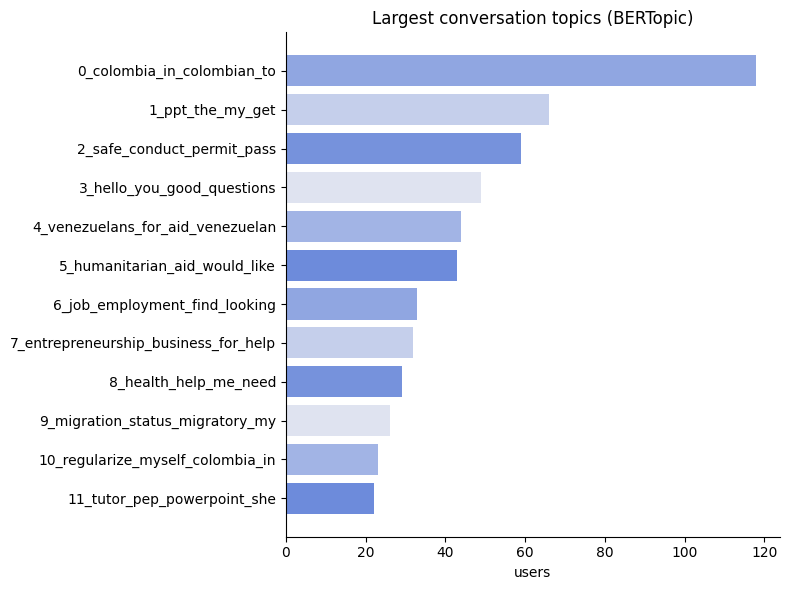

In [4]:
vis = topic_info[topic_info["Topic"] >= 0].head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(vis["Name"], vis["Count"], color=bar_colors(len(vis)))
ax.set_title("Largest conversation topics (BERTopic)")
ax.set_xlabel("users")
plt.tight_layout()

## 3. Mixed coding — MMC taxonomy + emergent topics

**What this shows.** Each auto-discovered topic mapped onto MMC's own
categories, with topics that don't fit flagged as *emergent*. **Why it matters.**
It keeps results comparable to MMC's existing framework while surfacing new
demand the taxonomy misses.

> **Technical note.** We seed the mapping from the human `Chat_summary` label
> that co-occurs most with each BERTopic topic, then hand-check a small sample.
> The crosswalk below is editable — adjust `TOPIC_TO_MMC` after review.
> BERTopic outliers and users who sent no message are not topics at all, so
> they are shown separately as "sin agrupar" / "sin mensaje"; a real topic is
> only flagged "emergent" when its dominant human label covers less than 50%
> of that topic's messages.

In [5]:
# normalize the existing human labels as the MMC category vocabulary
df["chat_norm"] = (df["Chat_summary"].astype(str)
                   .str.lower().str.lstrip("#").str.strip())

# Non-topic buckets: BERTopic outliers and users who sent no message are NOT
# topics and must not be counted as "emergent".
NON_TOPIC = {-1: "sin agrupar", -2: "sin mensaje"}
NON_TOPIC_CATS = list(NON_TOPIC.values())
EMERGENT_THRESHOLD = 0.5   # a topic whose most-common human label is weaker
                           # than this share is treated as genuinely emergent

def _seed_label(s):
    vc = s[~s.isin(["nan", ""])].value_counts(normalize=True)
    if len(vc) == 0 or vc.iloc[0] < EMERGENT_THRESHOLD:
        return "emergent"
    return vc.index[0]

# seed one MMC category per REAL topic (>= 0); editable after review
TOPIC_TO_MMC = (df[df["topic"] >= 0].groupby("topic")["chat_norm"]
                .agg(_seed_label).to_dict())

def _category(topic):
    if topic in NON_TOPIC:
        return NON_TOPIC[topic]
    return TOPIC_TO_MMC.get(topic, "emergent")

df["mmc_category"] = df["topic"].map(_category)

# validation sample: 8 random messages with topic + assigned category
sample = (df[df["topic"] >= 0]
          .sample(8, random_state=1)[["Text", "topic_label", "mmc_category"]])
display(sample)

,Text,topic_label,mmc_category
705,I would like to know what aid is being given a...,5_humanitarian_aid_would_like,humanitarian assistance
863,Where can I update my PPT card data,1_ppt_the_my_get,legal documentation
941,I am a Venezuelan citizen. I legally entered C...,0_colombia_in_colombian_to,legal documentation
456,I want to find an organization that can help m...,7_entrepreneurship_business_for_help,employment
358,It's about how to get a PowerPoint presentatio...,11_tutor_pep_powerpoint_she,emergent
740,I would like to know what type of financial as...,14_financial_aid_assistance_loan,emergent
79,"Hello, I want to know how to renew my SC2",2_safe_conduct_permit_pass,legal documentation
515,How do I apply for the safe-conduct pass?,2_safe_conduct_permit_pass,legal documentation


In [6]:
crosswalk = (df[df["topic"] >= 0]
             .groupby(["topic", "topic_label", "mmc_category"])
             .size().rename("users").reset_index()
             .sort_values("users", ascending=False))
display(crosswalk)
emergent_share = (df.loc[df["topic"] >= 0, "mmc_category"] == "emergent").mean() * 100
print(f"emergent (real topics not matching an MMC label): {emergent_share:.1f}% of clustered users")

,topic,topic_label,mmc_category,users
0,0,0_colombia_in_colombian_to,legal documentation,118
1,1,1_ppt_the_my_get,legal documentation,66
2,2,2_safe_conduct_permit_pass,legal documentation,59
3,3,3_hello_you_good_questions,emergent,49
4,4,4_venezuelans_for_aid_venezuelan,emergent,44
5,5,5_humanitarian_aid_would_like,humanitarian assistance,43
6,6,6_job_employment_find_looking,employment,33
7,7,7_entrepreneurship_business_for_help,employment,32
8,8,8_health_help_me_need,emergent,29
9,9,9_migration_status_migratory_my,legal documentation,26


emergent (real topics not matching an MMC label): 29.6% of clustered users


### 3.1 Cluster map

**What this shows.** The clustering from Section 2 drawn as a picture — every
user is one point, near-duplicate conversations sit together, and each point is
colored by the MMC category its cluster maps to. **Why it matters.** It's the
visual sanity check on the topic model: well-separated blobs mean the themes are
genuinely distinct, while the grey outlier cloud shows how much conversation
doesn't fit any clean cluster.

> **Technical note.** Purely for display we fit a second UMAP down to 2
> dimensions; the model in Section 2 used 5. Positions are approximate — read
> *grouping*, not exact coordinates.

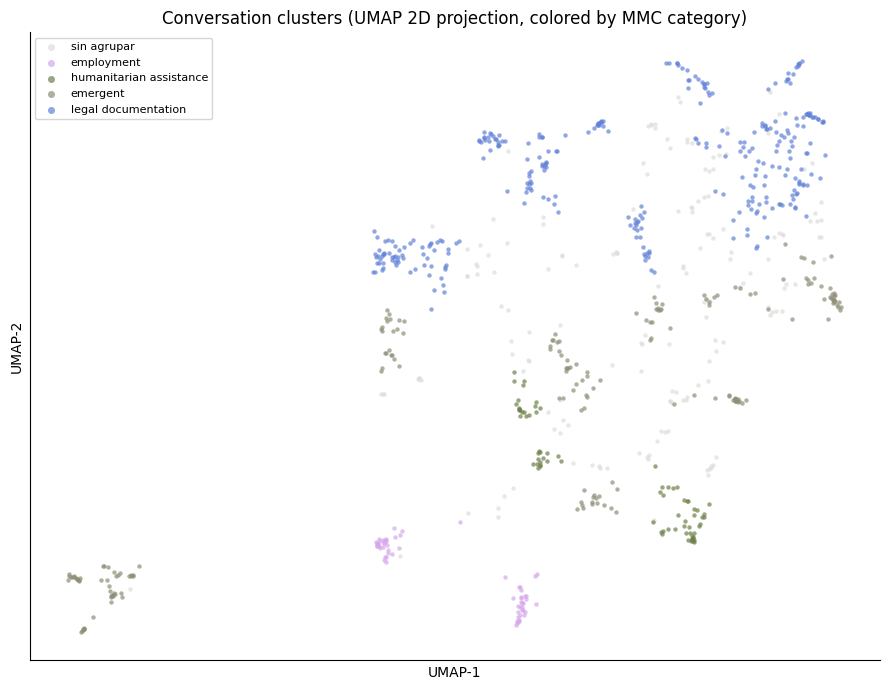

In [7]:
# 2D projection of the SAME embeddings used for clustering, so the clusters are
# visible as blobs. A separate 2-component UMAP is fit for display only (the
# model above reduced to 5 dims). Points are colored by the MMC category each
# cluster maps to, not by raw topic id: coloring ~19 topics would be unreadable,
# and category is the dimension every later section uses.
umap_2d = UMAP(n_neighbors=15, n_components=2, min_dist=0.0,
               metric='cosine', random_state=42).fit_transform(embeddings)
proj = pd.DataFrame(umap_2d, columns=["x", "y"])
proj["category"] = df.loc[docs_mask, "mmc_category"].values

CAT_COLORS = {
    "legal documentation":     AGUA,
    "humanitarian assistance": ARBOL,
    "employment":              AMEBA,
    "emergent":                MADERA,
    "sin agrupar":             HONGO,   # BERTopic outliers (topic -1)
}
fig, ax = plt.subplots(figsize=(9, 7))
# draw outliers first so the real clusters sit on top of them
for cat in ["sin agrupar", "employment", "humanitarian assistance",
            "emergent", "legal documentation"]:
    m = proj["category"] == cat
    if m.any():
        ax.scatter(proj.loc[m, "x"], proj.loc[m, "y"], s=10, alpha=0.7,
                   color=CAT_COLORS.get(cat, NEGRO), linewidths=0, label=cat)
ax.set_title("Conversation clusters (UMAP 2D projection, colored by MMC category)")
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
ax.legend(markerscale=1.6, fontsize=8, loc="best", frameon=True)
plt.tight_layout()

## 4. Most-requested needs (trámites & institutions)

**What this shows.** Which documents, procedures, and institutions people
mention most (PPT, EPS, Migración Colombia, …). **Why it matters.** It maps
real demand so MMC can prioritize content and referrals.

> **Technical note.** A curated dictionary (`mmc_entities.ENTITY_PATTERNS`)
> matches accent- and case-insensitively on the raw Spanish `Messages`. A
> message can mention several entities.

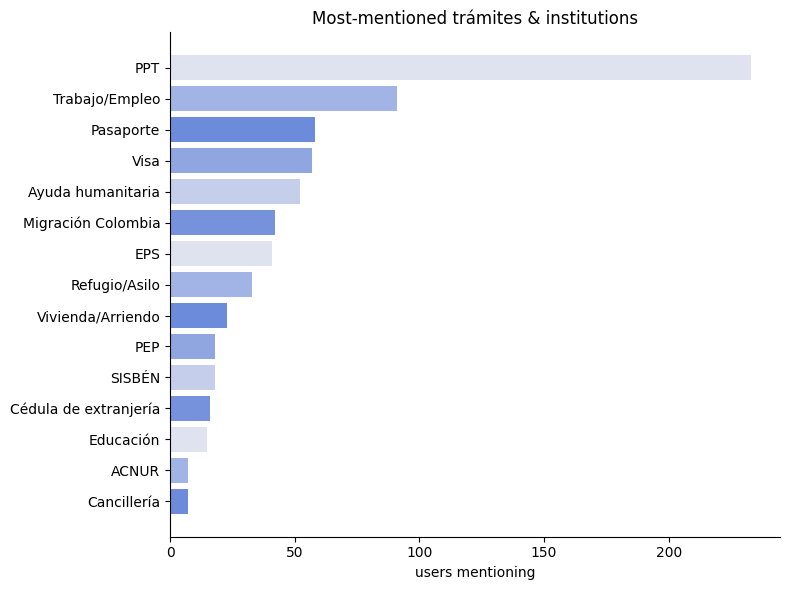

In [8]:
counts = mmc_entities.entity_counts(df["Messages"])
fig, ax = plt.subplots(figsize=(8, 6))
top = counts.head(15).iloc[::-1]
ax.barh(top.index, top.values, color=bar_colors(len(top)))
ax.set_title("Most-mentioned trámites & institutions")
ax.set_xlabel("users mentioning")
plt.tight_layout()

# add per-entity boolean columns for later cross-tabs
for ent in counts.index:
    col = "ent_" + ent
    df[col] = df["Messages"].fillna("").map(lambda t, e=ent: e in mmc_entities.extract_entities(t))

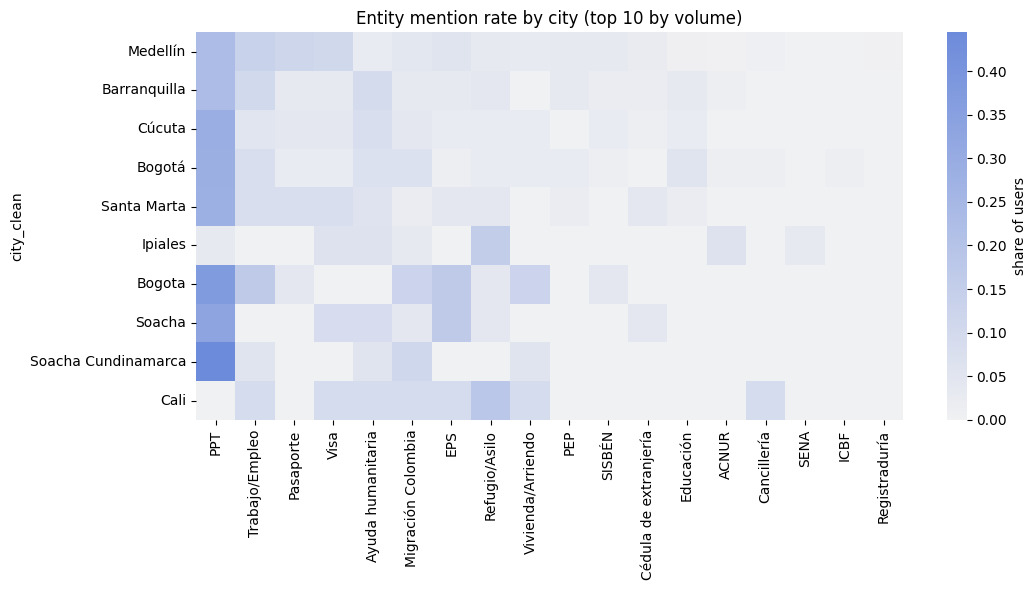

In [9]:
ent_cols = [c for c in df.columns if c.startswith("ent_")]
top_cities = df["city_clean"].value_counts().head(10).index
mat = (df[df["city_clean"].isin(top_cities)]
       .groupby("city_clean")[ent_cols].mean().loc[top_cities])
mat.columns = [c[4:] for c in mat.columns]
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(mat, cmap=sns.light_palette(BLUES[5], as_cmap=True),
            ax=ax, cbar_kws={"label": "share of users"})
ax.set_title("Entity mention rate by city (top 10 by volume)")
plt.tight_layout()

## 5. Geographic analysis by city

**What this shows.** Query volume and topic mix across the highest-volume
cities. **Why it matters.** MMC operates in priority cities; this compares
where demand concentrates and how needs differ by place.

> **Technical note.** Cities are ranked by user volume from the data. To pin the
> analysis to MMC's official 10 priority cities, replace `top_cities` with that
> list.

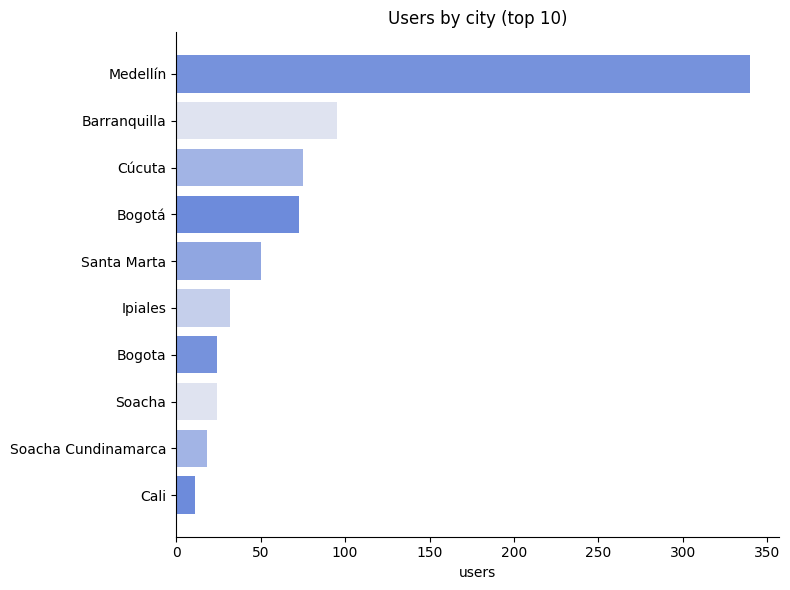

In [10]:
top_cities = df["city_clean"].value_counts().head(10)
fig, ax = plt.subplots(figsize=(8, 6))
order = top_cities.iloc[::-1]
ax.barh(order.index, order.values, color=bar_colors(len(order)))
ax.set_title("Users by city (top 10)")
ax.set_xlabel("users")
plt.tight_layout()

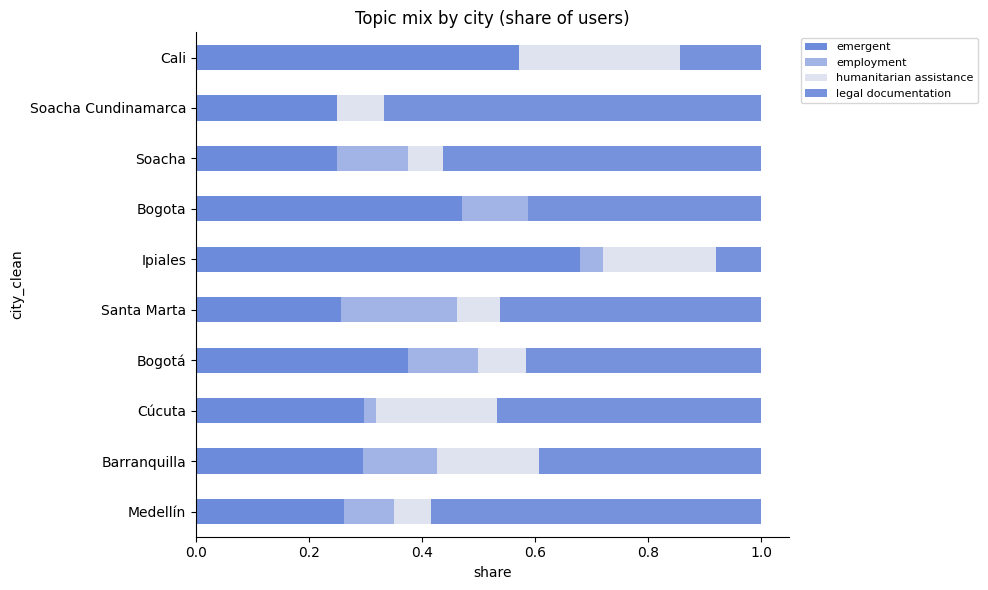

In [11]:
cats = df[~df["mmc_category"].isin(NON_TOPIC_CATS)]["mmc_category"].value_counts().head(6).index
sub = df[df["city_clean"].isin(top_cities.index) & df["mmc_category"].isin(cats)]
mix = (pd.crosstab(sub["city_clean"], sub["mmc_category"], normalize="index")
       .loc[top_cities.index])
mix.plot(kind="barh", stacked=True, figsize=(10, 6),
         color=bar_colors(mix.shape[1]))
plt.title("Topic mix by city (share of users)")
plt.xlabel("share")
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()

## 6. Temporal analysis — topics over time

**What this shows.** How overall volume and specific topics rise and fall by
date. **Why it matters.** Spikes often track migration-policy events; aligning
them helps MMC anticipate demand.

> **Technical note.** Time is the user's first-contact `Timestamp` (one per
> user), bucketed weekly. `EVENTS` is a manually curated overlay — extend it
> with confirmed policy dates.

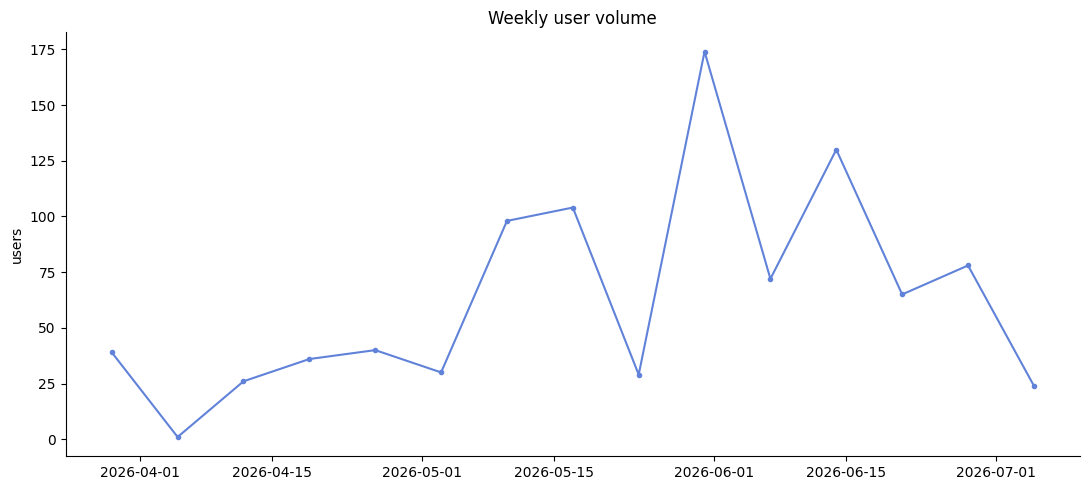

In [12]:
EVENTS = {
    # "2026-04-15": "example policy milestone",
}
ts = df.dropna(subset=["ts"]).set_index("ts")
weekly = ts.resample("W").size()
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(weekly.index, weekly.values, color=AGUA, marker="o", ms=3)
for date, label in EVENTS.items():
    ax.axvline(pd.Timestamp(date), color=MADERA, ls="--", lw=1)
    ax.text(pd.Timestamp(date), weekly.max(), label, rotation=90,
            va="top", fontsize=8)
ax.set_title("Weekly user volume")
ax.set_ylabel("users")
plt.tight_layout()

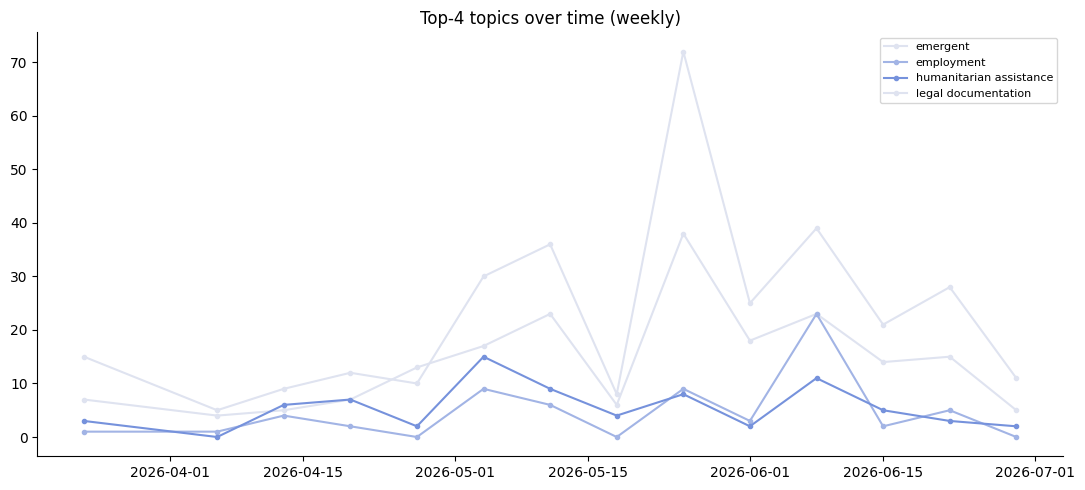

In [13]:
cats = df[~df["mmc_category"].isin(NON_TOPIC_CATS)]["mmc_category"].value_counts().head(4).index
trend = (df.dropna(subset=["ts"])
         .assign(week=lambda d: d["ts"].dt.to_period("W").dt.start_time)
         [lambda d: d["mmc_category"].isin(cats)]
         .groupby(["week", "mmc_category"]).size().unstack(fill_value=0))
fig, ax = plt.subplots(figsize=(11, 5))
for i, c in enumerate(trend.columns):
    ax.plot(trend.index, trend[c], marker="o", ms=3,
            color=BLUES[(i * 2) % len(BLUES)], label=c)
ax.set_title("Top-4 topics over time (weekly)")
ax.legend(fontsize=8)
plt.tight_layout()

## 7. Demographic profile vs. topic

**What this shows.** How topic demand differs by nationality, gender, and age
band. **Why it matters.** It reveals which segments ask about what, so outreach
and content can be tailored.

> **Technical note.** Cells are row-normalized (share of that group's users),
> so rows sum to 1 and small groups aren't visually swamped by large ones.

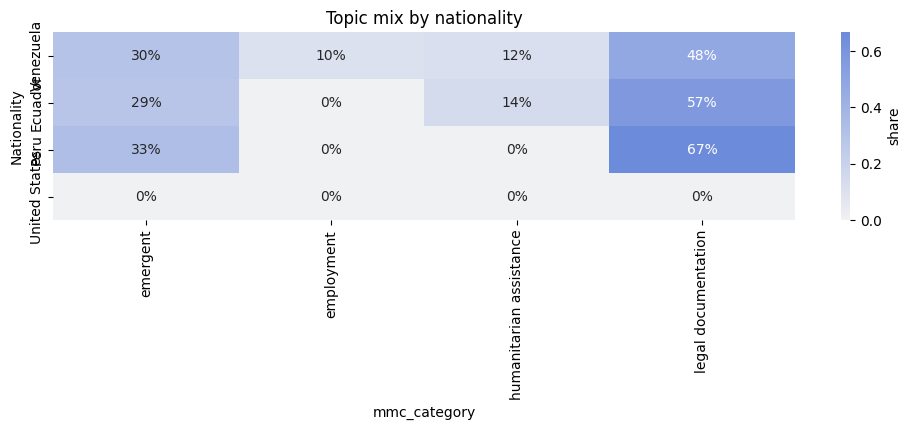

In [14]:
top_cats = df[~df["mmc_category"].isin(NON_TOPIC_CATS)]["mmc_category"].value_counts().head(6).index

def topic_heatmap(group_col, top_n=6, title=""):
    groups = df[group_col].value_counts().head(top_n).index
    sub = df[df[group_col].isin(groups) & df["mmc_category"].isin(top_cats)]
    mat = (pd.crosstab(sub[group_col], sub["mmc_category"], normalize="index")
           .reindex(groups, fill_value=0))
    fig, ax = plt.subplots(figsize=(10, 0.6 * len(groups) + 2))
    sns.heatmap(mat, cmap=sns.light_palette(BLUES[5], as_cmap=True),
                annot=True, fmt=".0%", ax=ax, cbar_kws={"label": "share"})
    ax.set_title(title)
    plt.tight_layout()

topic_heatmap("Nationality", title="Topic mix by nationality")

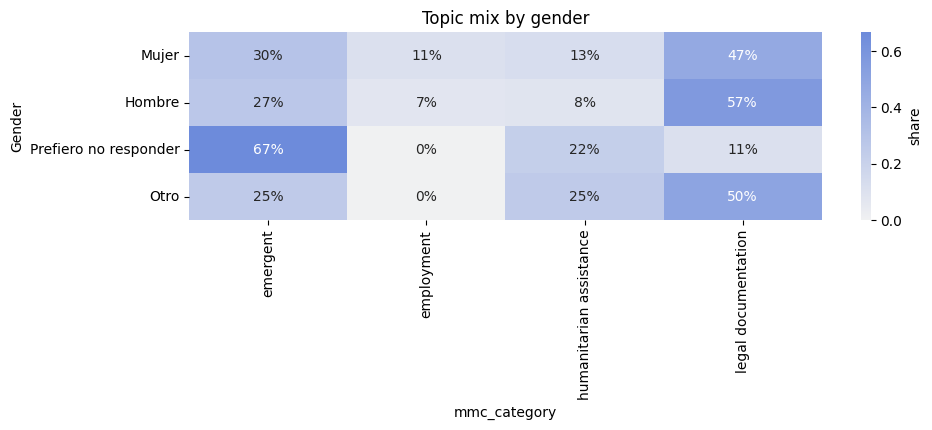

In [15]:
topic_heatmap("Gender", top_n=4, title="Topic mix by gender")

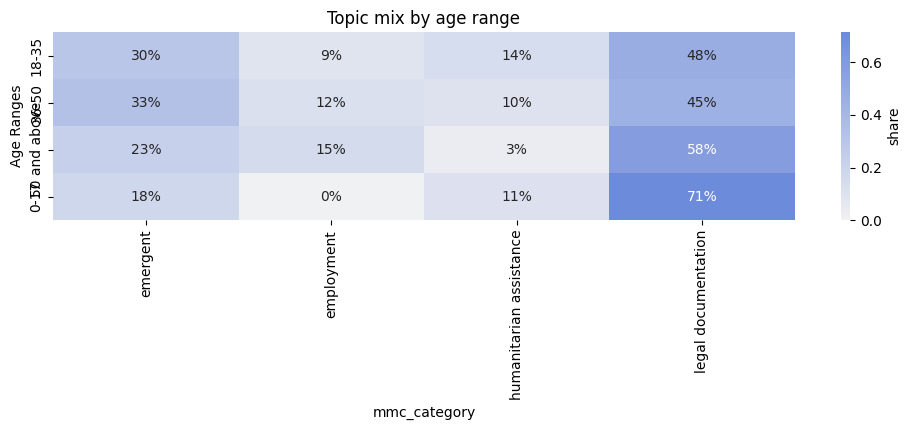

In [16]:
topic_heatmap("Age Ranges", top_n=4, title="Topic mix by age range")

## 8. Engagement depth (questions per user)

**What this shows.** How many questions each user asks before stopping, and how
many ask only once. **Why it matters.** Shallow engagement can signal friction —
but read it carefully.

> **Data gap — not turn-level drop-off.** We only have a per-user question
> *count*, not the ordered message sequence, so we cannot pinpoint *where* in a
> conversation people abandon. True drop-off analysis needs turn-level logs
> (see the final section).

median: 1  |  single-question share: 62.6%


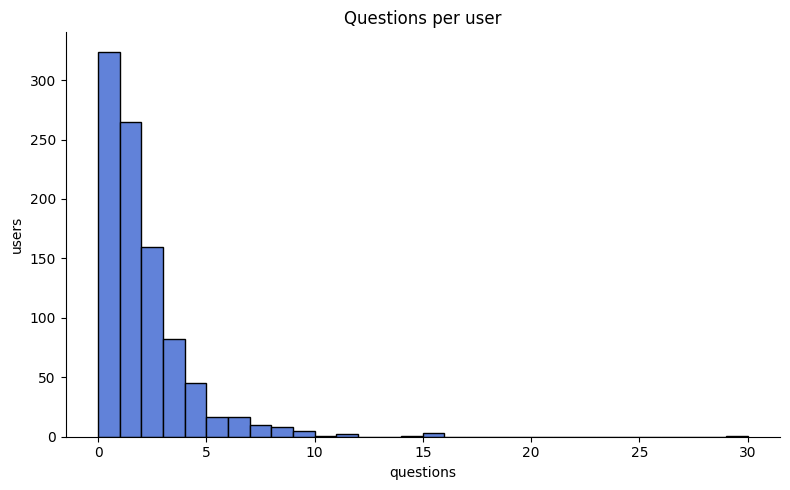

In [17]:
q = df["n_questions"].dropna()
fig, ax = plt.subplots(figsize=(8, 5))
bins = range(0, int(q.max()) + 2)
ax.hist(q, bins=bins, color=AGUA, edgecolor=NEGRO)
ax.set_title("Questions per user")
ax.set_xlabel("questions"); ax.set_ylabel("users")
plt.tight_layout()
print(f"median: {q.median():.0f}  |  single-question share: "
      f"{(q <= 1).mean() * 100:.1f}%")

## 9. Repeated / reformulated questions (heuristic)

**What this shows.** Users who rephrase the same question several times — a hint
they didn't get a useful answer. **Why it matters.** Clusters of reformulation
point at content gaps or unclear bot replies.

> **Technical note — heuristic.** We split each user's messages, embed them, and
> count consecutive pairs with cosine similarity ≥ 0.75. This approximates
> "asked the same thing again"; it is not a verified intent match.

In [18]:
def user_reformulations(blob):
    msgs = mmc_text.split_messages(blob)
    if len(msgs) < 2:
        return 0, len(msgs)
    emb = embedder.encode(msgs, show_progress_bar=False)
    return mmc_text.count_reformulations(emb, threshold=0.75), len(msgs)

res = df["Messages"].map(user_reformulations)
df["n_reformulations"] = [r[0] for r in res]
df["n_msgs"] = [r[1] for r in res]

reform_users = (df["n_reformulations"] > 0).mean() * 100
print(f"users with >=1 reformulated pair: {reform_users:.1f}%")
display(df[df["n_reformulations"] > 0]
        .sort_values("n_reformulations", ascending=False)
        [["city_clean", "mmc_category", "n_msgs", "n_reformulations"]].head(10))

users with >=1 reformulated pair: 11.8%


,city_clean,mmc_category,n_msgs,n_reformulations
63,Maicao,emergent,17,6
244,Barranquilla,emergent,31,4
874,Medellín,employment,17,4
218,Medellín,legal documentation,43,3
158,Bogotá,emergent,9,3
355,Bogotá,employment,8,3
595,Medellín,legal documentation,10,3
30,Medellín,sin mensaje,8,3
657,Medellín,emergent,10,3
181,Medellín,legal documentation,11,2


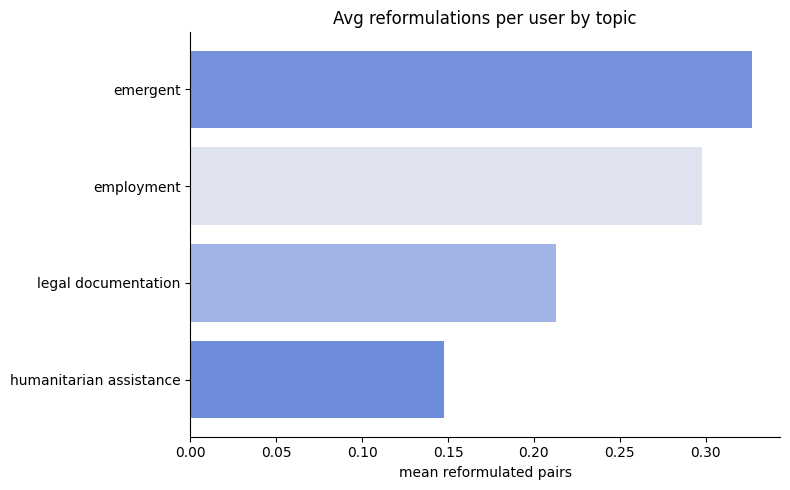

In [19]:
by_topic = (df[(df["n_msgs"] >= 2) & (~df["mmc_category"].isin(NON_TOPIC_CATS))]
            .groupby("mmc_category")["n_reformulations"]
            .mean().sort_values(ascending=False).head(10).iloc[::-1])
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(by_topic.index, by_topic.values, color=bar_colors(len(by_topic)))
ax.set_title("Avg reformulations per user by topic")
ax.set_xlabel("mean reformulated pairs")
plt.tight_layout()

## 10. Sentiment analysis

**What this shows.** The emotional tone of what users write — negative, neutral,
or positive — overall and by topic. **Why it matters.** Tone is an *unsolicited*
signal of distress and urgency; unlike the MEAL survey (only a few dozen users)
it covers everyone who wrote a message, and it flags which needs arrive with the
most frustration.

> **Technical note.** We score the raw Spanish `Messages` with
> `cardiffnlp/twitter-xlm-roberta-base-sentiment`, a multilingual model tuned
> for short, informal text. Each user's messages are concatenated and truncated
> to 512 tokens, so this is a per-user tone *summary*, not per-message.
> Sentiment reflects the **user's** wording only — we have no bot replies — so
> read it as "how the person arrived," not "how the bot made them feel."

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

sentiment
negative    180
neutral     645
positive     10
Name: count, dtype: int64
negative share: 21.6%


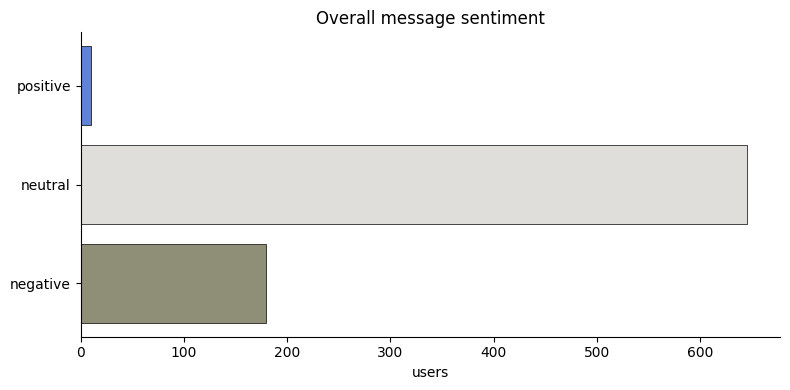

In [20]:
from transformers import pipeline

sent_mask = df["Messages"].notna() & (df["Messages"].astype(str).str.len() > 0)
sent_docs = df.loc[sent_mask, "Messages"].astype(str).tolist()

sentiment_clf = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-xlm-roberta-base-sentiment",
    truncation=True, max_length=512,
)
preds = sentiment_clf(sent_docs, batch_size=32)

def _norm_sent(label):
    l = label.lower()
    if "neg" in l or l.endswith("0"):
        return "negative"
    if "pos" in l or l.endswith("2"):
        return "positive"
    return "neutral"

SENT_ORDER = ["negative", "neutral", "positive"]
SENT_COLORS = {"negative": MADERA, "neutral": HONGO, "positive": AGUA}

df["sentiment"] = pd.NA
df.loc[sent_mask, "sentiment"] = [_norm_sent(p["label"]) for p in preds]

dist = df["sentiment"].value_counts().reindex(SENT_ORDER)
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(SENT_ORDER, dist.values, color=[SENT_COLORS[s] for s in SENT_ORDER],
        edgecolor=NEGRO, linewidth=0.5)
ax.set_title("Overall message sentiment")
ax.set_xlabel("users")
plt.tight_layout()
print(dist)
print(f"negative share: {dist['negative'] / dist.sum() * 100:.1f}%")

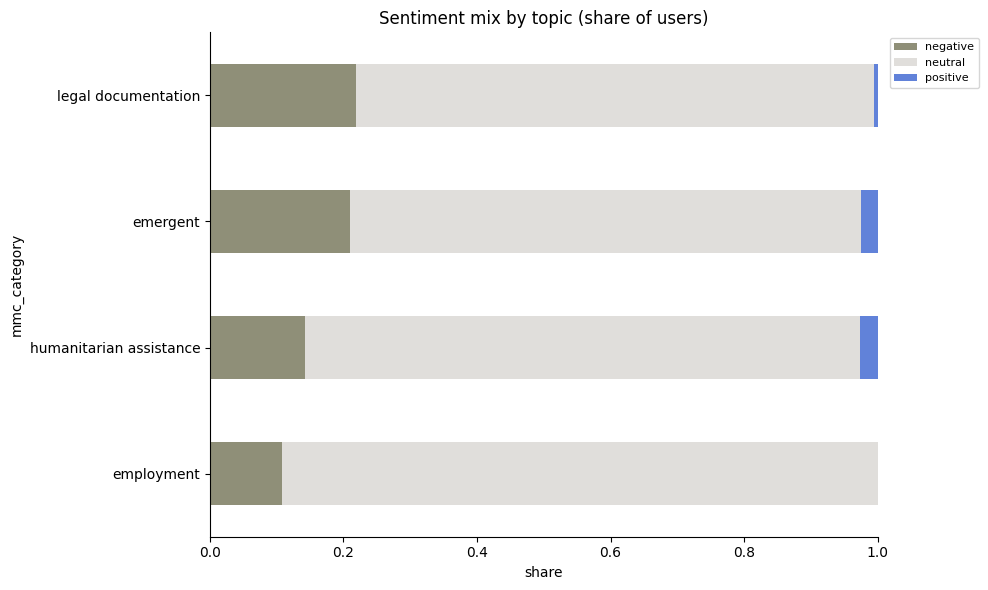

In [21]:
# Sentiment mix per topic — which themes arrive with the most negative tone.
cats = df[~df["mmc_category"].isin(NON_TOPIC_CATS)]["mmc_category"].value_counts().head(6).index
sub = df[df["mmc_category"].isin(cats) & df["sentiment"].notna()].copy()
sub["sentiment"] = sub["sentiment"].astype(str)
tab = (pd.crosstab(sub["mmc_category"], sub["sentiment"], normalize="index")
       .reindex(columns=SENT_ORDER, fill_value=0)
       .loc[cats].iloc[::-1])
tab.plot(kind="barh", stacked=True, figsize=(10, 6),
         color=[SENT_COLORS[s] for s in SENT_ORDER])
plt.title("Sentiment mix by topic (share of users)")
plt.xlabel("share")
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()

users with both sentiment and MEAL rating: 94


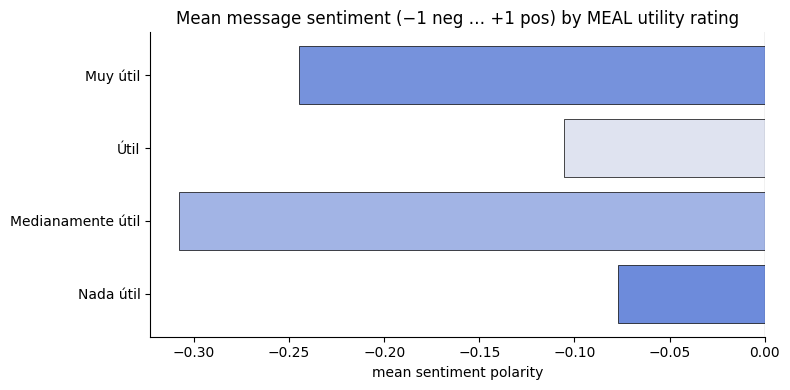

In [22]:
# Cross-check: does the message tone we inferred track the MEAL utility rating
# people gave? Only users present in both datasets (small overlap).
UTIL_ORDER = ["Nada útil", "Medianamente útil", "Útil", "Muy útil"]
SENT_SIGN = {"negative": -1, "neutral": 0, "positive": 1}

sval = df.merge(meal[["phone", "utility"]], on="phone", how="inner")
sval = sval[sval["sentiment"].notna() & sval["utility"].isin(UTIL_ORDER)].copy()
sval["sent_sign"] = sval["sentiment"].astype(str).map(SENT_SIGN)
by_util = sval.groupby("utility")["sent_sign"].mean().reindex(UTIL_ORDER).dropna()
print(f"users with both sentiment and MEAL rating: {len(sval)}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(by_util.index, by_util.values, color=bar_colors(len(by_util)),
        edgecolor=NEGRO, linewidth=0.5)
ax.axvline(0, color=NEGRO, lw=0.8)
ax.set_title("Mean message sentiment (−1 neg … +1 pos) by MEAL utility rating")
ax.set_xlabel("mean sentiment polarity")
plt.tight_layout()

## 11. Satisfaction (MEAL) × topic

**What this shows.** Utility ratings joined to the topic each user asked about.
**Why it matters.** It flags which topics produce the worst experience.

> **Technical note — small overlap.** Only users who completed the MEAL survey
> appear here (dozens, not hundreds). Read proportions as directional, not
> precise. Joined on WhatsApp phone number.

users with both topic and MEAL rating: 105


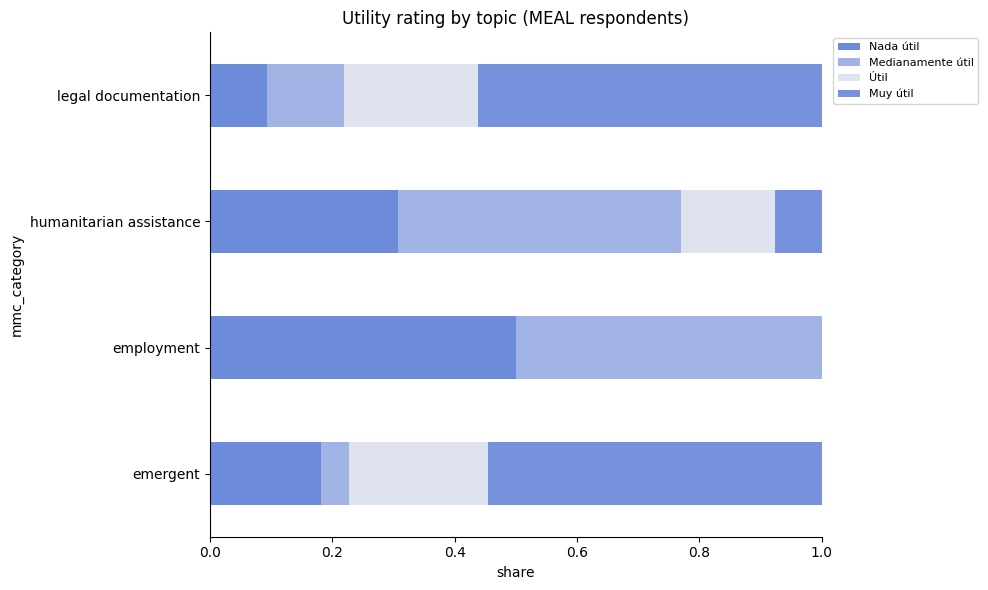

In [23]:
UTIL_ORDER = ["Nada útil", "Medianamente útil", "Útil", "Muy útil"]
merged = df.merge(meal[["phone", "utility"]], on="phone", how="inner")
print(f"users with both topic and MEAL rating: {len(merged)}")

merged["utility"] = pd.Categorical(merged["utility"], UTIL_ORDER, ordered=True)
cats = merged[~merged["mmc_category"].isin(NON_TOPIC_CATS)]["mmc_category"].value_counts().head(6).index
sub = merged[merged["mmc_category"].isin(cats)]
tab = pd.crosstab(sub["mmc_category"], sub["utility"], normalize="index").reindex(columns=UTIL_ORDER, fill_value=0)
tab.plot(kind="barh", stacked=True, figsize=(10, 6), color=bar_colors(4))
plt.title("Utility rating by topic (MEAL respondents)")
plt.xlabel("share"); plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()

## 12. Geographic clustering — sentiment & topic on the map

**What this shows.** The two headline dimensions placed on Colombia: each city's
**dominant need** (MMC topic) and the **average tone** of its users (sentiment).
**Why it matters.** It turns the city cross-tabs from Section 5 into a map — you
can see at a glance where a given need concentrates and where people write in
with the most negative tone, which helps target field response.

> **Technical note.** One bubble per city (size = number of users), positioned
> from a curated coordinate table for Colombia's main cities. Only cities with
> at least 8 mapped users are shown, so each average rests on enough people to
> read. Sentiment is the mean per-user polarity (−1 / 0 / +1) from Section 10;
> topic is the most common MMC category from Section 3. Cities without
> coordinates in the table are omitted — extend `CITY_COORDS` to add them. The
> Colombia outline is fetched once via OpenStreetMap and cached under `cache/`.

In [24]:
import os, unicodedata
import geopandas as gpd

# 1. Curated coordinates (lon, lat) for Colombia's main cities. A small lookup is
#    used instead of live geocoding so the map is reproducible and never depends
#    on a name-matching service resolving accents / spelling variants at runtime.
CITY_COORDS = {
    "bogota": (-74.0721, 4.7110),   "medellin": (-75.5812, 6.2442),
    "cali": (-76.5320, 3.4516),     "barranquilla": (-74.7813, 10.9685),
    "cartagena": (-75.4794, 10.3910),"cucuta": (-72.5078, 7.8939),
    "bucaramanga": (-73.1227, 7.1193),"maicao": (-72.2382, 11.3776),
    "riohacha": (-72.9072, 11.5449),"ipiales": (-77.6417, 0.8256),
    "pasto": (-77.2811, 1.2136),    "santa marta": (-74.1990, 11.2408),
    "villavicencio": (-73.6266, 4.1420),"pereira": (-75.6906, 4.8087),
    "manizales": (-75.5138, 5.0703),"armenia": (-75.6811, 4.5339),
    "ibague": (-75.2322, 4.4389),   "soledad": (-74.7647, 10.9174),
    "soacha": (-74.2168, 4.5794),   "valledupar": (-73.2532, 10.4631),
    "monteria": (-75.8814, 8.7479), "sincelejo": (-75.3978, 9.3047),
    "tunja": (-73.3678, 5.5353),    "neiva": (-75.2819, 2.9273),
    "popayan": (-76.6147, 2.4448),  "arauca": (-70.7591, 7.0847),
    "yopal": (-72.3959, 5.3378),    "florencia": (-75.6062, 1.6144),
    "quibdo": (-76.6611, 5.6947),   "apartado": (-76.6255, 7.8829),
    "turbo": (-76.7286, 8.0917),    "necocli": (-76.7889, 8.4245),
    "barrancabermeja": (-73.8547, 7.0653),"buenaventura": (-77.0313, 3.8801),
    "tulua": (-76.1954, 4.0847),    "palmira": (-76.3036, 3.5394),
    "bello": (-75.5636, 6.3373),
}

def _strip_accents(s):
    s = str(s).strip().lower()
    return "".join(c for c in unicodedata.normalize("NFKD", s)
                   if not unicodedata.combining(c))

df["city_norm"] = df["city_clean"].map(_strip_accents)
geo_matched = df["city_norm"].isin(CITY_COORDS)
print(f"{df.loc[geo_matched, 'city_norm'].nunique()} cities have coordinates, "
      f"covering {geo_matched.mean() * 100:.0f}% of users")

# 2. Colombia outline: read from cache if present, else fetch once via OSM and
#    cache it (the notebook already downloads models at runtime, so a one-time
#    boundary fetch is consistent). If it fails, bubbles still plot without it.
COL_CACHE = "cache/colombia_boundary.gpkg"
colombia = None
try:
    if os.path.exists(COL_CACHE):
        colombia = gpd.read_file(COL_CACHE)
    else:
        import osmnx as ox
        colombia = ox.geocode_to_gdf("Colombia")[["geometry"]]
        os.makedirs("cache", exist_ok=True)
        colombia.to_file(COL_CACHE, driver="GPKG")
except Exception as e:
    print("Colombia outline unavailable, plotting bubbles only:", repr(e)[:120])

# 3. Aggregate to one row per city. Only real-topic users (drop sin agrupar /
#    sin mensaje) and only cities with >= MIN_USERS, so each city average rests
#    on enough people to be readable rather than a single loud user.
MIN_USERS = 8
SENT_SIGN = {"negative": -1, "neutral": 0, "positive": 1}

g = df[geo_matched & ~df["mmc_category"].isin(NON_TOPIC_CATS)].copy()
g["sent_sign"] = (g["sentiment"].map(SENT_SIGN)
                  if "sentiment" in g.columns else np.nan)
geo = g.groupby("city_norm").agg(users=("city_norm", "size"),
                                 sentiment=("sent_sign", "mean"))
geo = geo[geo["users"] >= MIN_USERS]
geo["dominant"] = (g.groupby("city_norm")["mmc_category"]
                   .agg(lambda s: s.value_counts().index[0]))
geo["lon"] = [CITY_COORDS[c][0] for c in geo.index]
geo["lat"] = [CITY_COORDS[c][1] for c in geo.index]
geo["label"] = [c.title() for c in geo.index]
geo = geo.sort_values("users", ascending=False)

def _basemap(ax, title):
    if colombia is not None:
        colombia.plot(ax=ax, color=MADERA_LIGHT, edgecolor=MADERA, lw=0.6, zorder=0)
    ax.set_title(title); ax.set_axis_off()
    ax.set_xlim(-80, -66); ax.set_ylim(-4.5, 13)

def _bubble_sizes(frame):
    return 60 + (frame["users"] / frame["users"].max()) * 900

print(f"{len(geo)} cities with >= {MIN_USERS} users mapped")
display(geo[["label", "users", "sentiment", "dominant"]].reset_index(drop=True))

22 cities have coordinates, covering 81% of users
7 cities with >= 8 users mapped


,label,users,sentiment,dominant
0,Medellin,245,-0.171429,legal documentation
1,Bogota,65,-0.200000,legal documentation
2,Barranquilla,61,-0.147541,legal documentation
3,Cucuta,47,-0.212766,legal documentation
4,Santa Marta,39,-0.282051,legal documentation
5,Ipiales,25,-0.280000,emergent
6,Soacha,16,0.000000,legal documentation


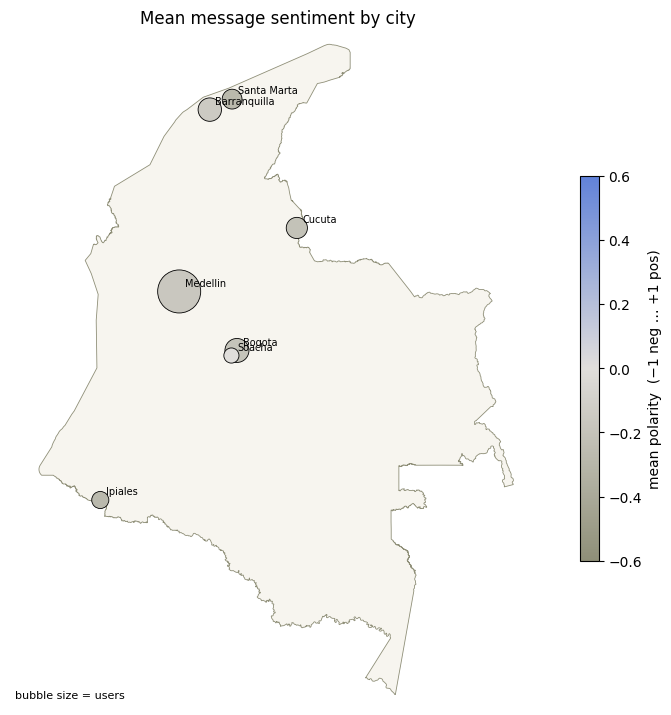

In [25]:
# Map 1 — mean message sentiment per city. Diverging scale: negative -> neutral ->
# positive reuses the Section 10 sentiment colors (MADERA / HONGO / AGUA).
from matplotlib.colors import LinearSegmentedColormap

if geo["sentiment"].notna().any():
    sent_cmap = LinearSegmentedColormap.from_list("mmc_sent", [MADERA, HONGO, AGUA])
    fig, ax = plt.subplots(figsize=(7, 8))
    _basemap(ax, "Mean message sentiment by city")
    sc = ax.scatter(geo["lon"], geo["lat"], s=_bubble_sizes(geo),
                    c=geo["sentiment"], cmap=sent_cmap, vmin=-0.6, vmax=0.6,
                    edgecolor=NEGRO, linewidth=0.6, zorder=2)
    for _, r in geo.iterrows():
        ax.annotate(r["label"], (r["lon"], r["lat"]), fontsize=7,
                    xytext=(4, 4), textcoords="offset points")
    cbar = plt.colorbar(sc, ax=ax, shrink=0.5)
    cbar.set_label("mean polarity  (−1 neg … +1 pos)")
    ax.text(0.01, 0.01, "bubble size = users", transform=ax.transAxes, fontsize=8)
    plt.tight_layout()
else:
    print("No sentiment column found — run Section 10 first to see the sentiment map.")

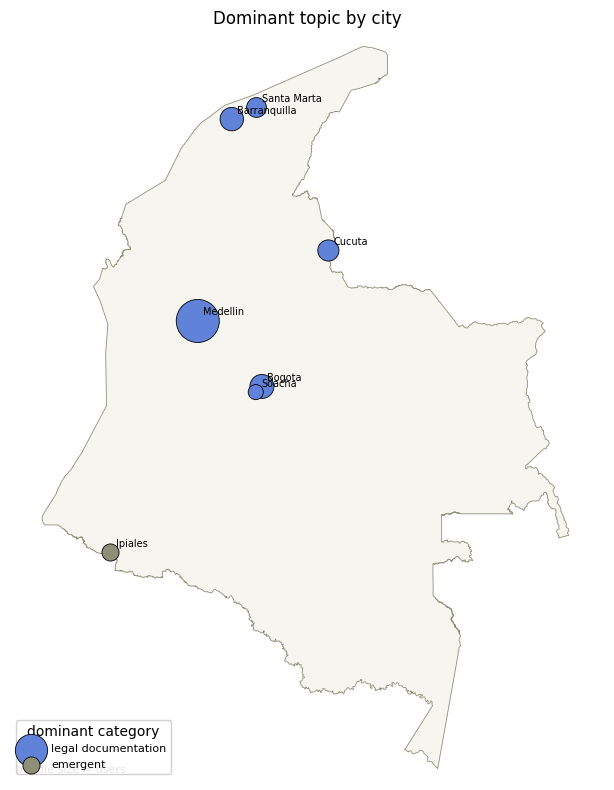

In [26]:
# Map 2 — dominant topic per city. Colored by the SAME MMC-category palette used
# in the Section 3.1 cluster map, so the two views read together.
TOPIC_COLORS = {
    "legal documentation":     AGUA,
    "humanitarian assistance": ARBOL,
    "employment":              AMEBA,
    "emergent":                MADERA,
}
fig, ax = plt.subplots(figsize=(7, 8))
_basemap(ax, "Dominant topic by city")
sizes = _bubble_sizes(geo)
for cat, col in TOPIC_COLORS.items():
    m = geo["dominant"] == cat
    if m.any():
        ax.scatter(geo.loc[m, "lon"], geo.loc[m, "lat"], s=sizes[m],
                   color=col, edgecolor=NEGRO, linewidth=0.6, label=cat, zorder=2)
for _, r in geo.iterrows():
    ax.annotate(r["label"], (r["lon"], r["lat"]), fontsize=7,
                xytext=(4, 4), textcoords="offset points")
ax.legend(loc="lower left", fontsize=8, framealpha=0.9, title="dominant category")
ax.text(0.01, 0.01, "bubble size = users", transform=ax.transAxes, fontsize=8)
plt.tight_layout()

## 13. Data gaps & limitations

Some analyses MMC may want are **not possible with the current export** because
it is user-level and contains no bot output. Documented here so they can be
planned for:

- **Fallback / no-response rate by topic** — needs the bot's replies (or an
  explicit "no answer" flag) per message. Not in the data.
- **Response consistency (same question, different answers)** — needs bot
  output text to compare. Not in the data.
- **True drop-off / abandonment point** — needs the ordered turn-by-turn log
  (which message a user stopped at), not just a per-user question count.

What *would* unlock them: a turn-level conversation log with, per turn, the user
message, the bot response, a fallback flag, and a timestamp.